# 02 — Variance

## What is variance?

The mean tells us **where** data is centred. Variance tells us **how spread out**
the data is around that centre.

### Formula

$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

Steps:
1. Subtract the mean from each value → **deviation**
2. Square each deviation (makes negatives positive, penalises large gaps)
3. Average the squared deviations

### Population vs Sample variance

| Version | Denominator | When to use |
|---------|------------|-------------|
| Population | $n$ | You have **all** the data |
| Sample | $n-1$ (Bessel's correction) | You have a **sample** and want to estimate the true population variance |

In ML we usually use population variance for normalization.

---

In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from utils.ml_utils import calculate_mean, calculate_variance
from utils.plotting import plot_histogram, plot_boxplot

In [4]:
df = pd.read_csv('../data/fundamentals_data.csv')
scores = df['student_score'].values

## Step 1 — Manual variance

In [5]:
mu          = calculate_mean(scores)
deviations  = scores - mu                  # step 1
sq_dev      = deviations ** 2              # step 2
variance    = sq_dev.mean()               # step 3 (population)

print(f'Mean              : {mu:.2f}')
print(f'Max deviation     : {deviations.max():.2f}')
print(f'Min deviation     : {deviations.min():.2f}')
print(f'Variance (manual) : {variance:.2f}')
print(f'Variance (numpy)  : {np.var(scores):.2f}')
print(f'Variance (custom) : {calculate_variance(scores):.2f}')

Mean              : 69.30
Max deviation     : 24.90
Min deviation     : -20.80
Variance (manual) : 123.12
Variance (numpy)  : 123.12
Variance (custom) : 123.12


## Step 2 — Low vs High variance

Two datasets with the **same mean** but very different spreads.

In [6]:
np.random.seed(0)
low_var  = np.random.normal(70, 3,  50)   # tight cluster
high_var = np.random.normal(70, 20, 50)   # wide spread

print(f'Low  variance dataset  — mean: {low_var.mean():.1f},  var: {low_var.var():.1f}')
print(f'High variance dataset  — mean: {high_var.mean():.1f}, var: {high_var.var():.1f}')

Low  variance dataset  — mean: 70.4,  var: 11.4
High variance dataset  — mean: 69.6, var: 300.7


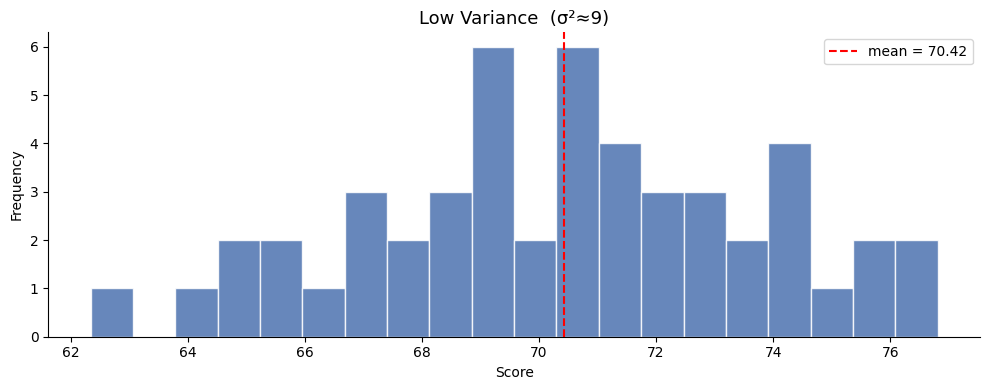

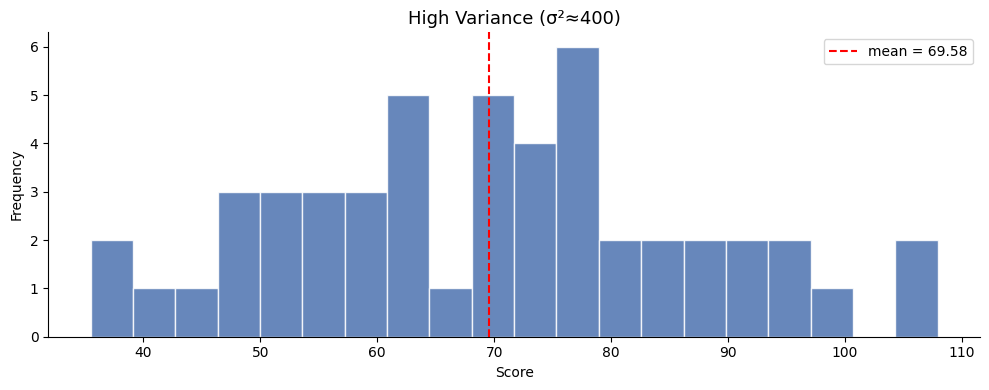

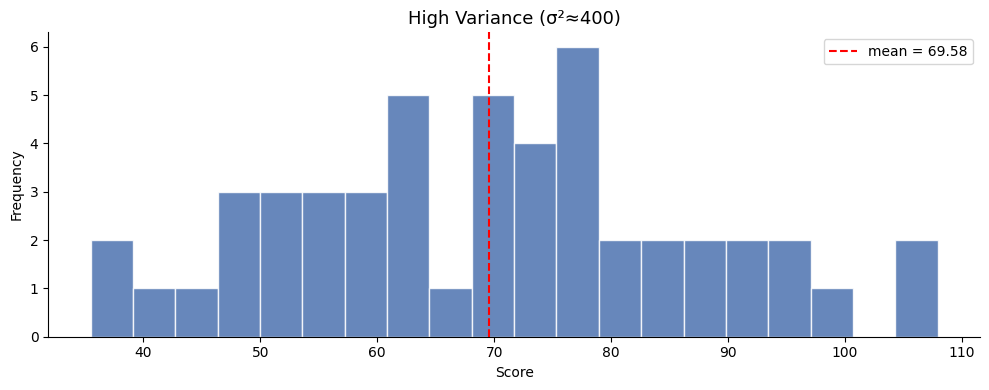

In [7]:
plot_histogram(low_var,  title='Low Variance  (σ²≈9)',  xlabel='Score')
plot_histogram(high_var, title='High Variance (σ²≈400)', xlabel='Score')

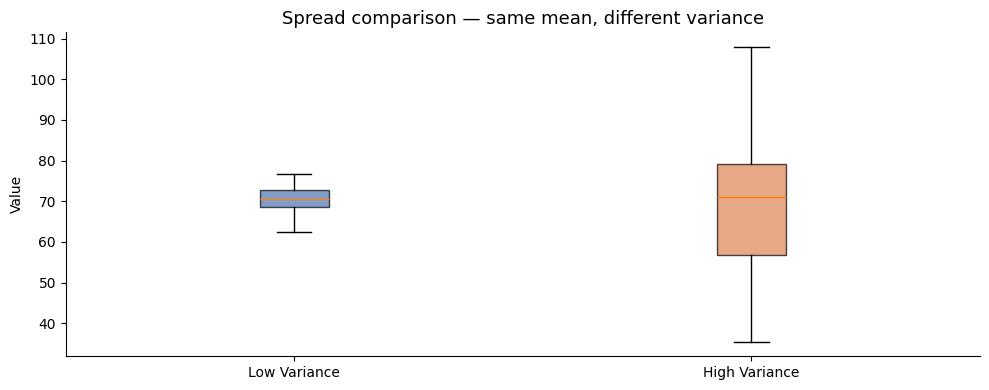

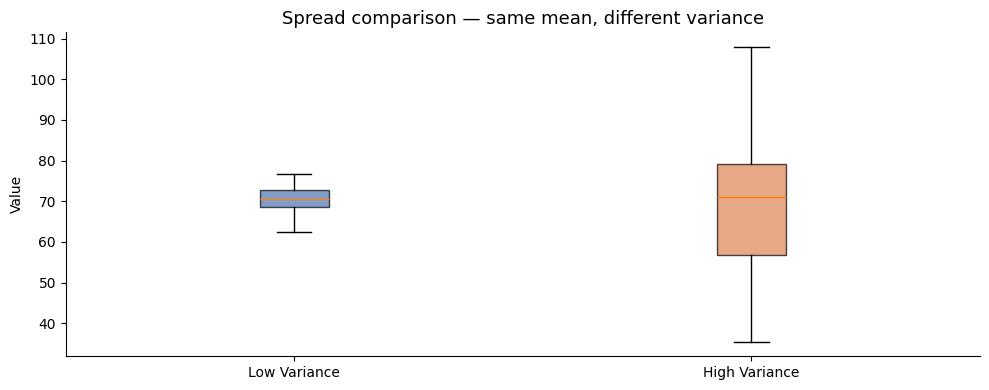

In [8]:
plot_boxplot(
    {'Low Variance': low_var, 'High Variance': high_var},
    title='Spread comparison — same mean, different variance'
)

## Step 3 — Why squared deviations?

If we summed raw deviations $(x_i - \bar{x})$, positive and negative values cancel
to zero — not useful. Squaring solves two things:

1. All values become **positive**
2. **Larger deviations** are penalised more heavily

The downside: units are now squared (e.g., scores² instead of scores).
Taking the square root gives us **standard deviation** — back in the original units.

In [9]:
print('Variance of each column:')
for col in df.columns:
    v = calculate_variance(df[col].values)
    print(f'  {col:<15} σ² = {v:.2f}')

Variance of each column:
  student_score   σ² = 123.12
  temperature     σ² = 18.72
  sales           σ² = 14538.22
  stock_price     σ² = 704.48


---
## Exercises

1. Why is variance always non-negative?
2. If you add a constant (e.g., +10) to every value, does the variance change? Test it.
3. If you multiply every value by 2, how does variance change? (Hint: think about the formula.)
4. Compute the **sample** variance (`ddof=1`) for `scores` and compare to population variance.

---
**Next →** `03_standard_deviation.ipynb`